In [89]:
import pandas as pd
import nfl_data_py as nfl
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [47]:
import sqlite3
import pandas as pd
DATABASE_NAME = 'odds.db'
#SOURCE_DB = r'C:\Users\rfo7799\Downloads\odds.db'

conn = sqlite3.connect(DATABASE_NAME)
table_name = 'player_props'
prop_df = pd.read_sql(f"""
                 SELECT * FROM {table_name} WHERE market_type = 'player_pass_yds'
                 --AND lower(event_name) like '%tit%'
                 """, conn)
#prop_df


In [48]:
#years = [2022, 2023, 2024, 2025]
#pbp = nfl.import_pbp_data(years=years, downcast=True)
#season = nfl.import_seasonal_data(years=years, s_type = 'REG')
#weekly = nfl.import_weekly_data(years=years)

#print('Play by Play Shape and Sample', pbp.shape, list())
#print('Season sample:')
#print(season.head(3))
#print('Weekly sample:')
#print(weekly.head(3))

#top_pass_2024 = (
#    weekly.query("season == 2024 and season_type == 'REG' and position == 'QB'")
#    .groupby(['player_id', 'player_display_name'], as_index=False)['passing_yards']
#    .sum()
#    .sort_values('passing_yards', ascending=False)
#)

#top_pass_2024.head()



In [49]:
# Select only the relevant columns
columns = ['passer_player_name', 'game_id', 'posteam', 'defteam', 'season', 'week', 'home_team', 'away_team', 'play_type', 'air_yards', 
           'yards_after_catch', 'epa', 'complete_pass', 'incomplete_pass', 'interception', 'qb_hit', 'sack', 'pass_touchdown',
           'passing_yards', 'cpoe', 'roof', 'surface','drive','game_seconds_remaining']

# Loading in the NFL pbp data
data = nfl.import_pbp_data(range(2010,2026), downcast=True)
data = data[columns]

# nfl-data-py still loads other columns, so we again need to set our data equal to only the columns we want
data = data[columns]

# Drop all rows that are not a pass
data = data[(data['play_type'] == 'pass')]

# Drop the play type column
passer_data = data.drop(columns=['play_type'])

2010 done.
2011 done.
2012 done.
2013 done.
2014 done.
2015 done.
2016 done.
2017 done.
2018 done.
2019 done.
2020 done.
2021 done.
2022 done.
2023 done.
2024 done.
2025 done.
Downcasting floats.


In [50]:
# Group the data together by passer, week, season and aggregate
passer_df = passer_data.groupby(['passer_player_name', 'game_id', 'week', 'season'], as_index=False).agg(
    {'posteam' : 'first',
     'defteam' : 'first',
     'home_team' : 'first',
     'away_team' : 'first',
     'air_yards' : 'sum',
     'yards_after_catch' : 'sum',
     'epa' : 'sum',
     'complete_pass' : 'sum',
     'incomplete_pass' : 'sum',
     'interception' : 'sum',
     'qb_hit' : 'sum',
     'sack' : 'sum',
     'pass_touchdown' : 'sum',
     'passing_yards' : 'sum',
     'cpoe' : 'mean',
     'roof' : 'first',
     'surface' : 'first'
     }
)

# Create a new column that is completion percentage
passer_df['completion_percentage'] = passer_df['complete_pass'] / (passer_df['complete_pass'] + passer_df['incomplete_pass'])

# Create a new column that is the number of pass attempts
passer_df['pass_attempts'] = passer_df['complete_pass'] + passer_df['incomplete_pass']

# Drop the complete_pass and incomplete_pass columns
passer_df = passer_df.drop(columns=['complete_pass', 'incomplete_pass'])

# Create a new column that equals 1 if the passer is the home team and 0 if the passer is the away team
passer_df['home_flag'] = passer_df['home_team'] == passer_df['posteam']

passer_df = passer_df.drop(columns=['home_team','away_team'])



# Reorder the columns
#passer_df = passer_df[['passer_player_name', 'posteam', 'defteam', 'season', 'week', 'passing_yards', 'home_flag', 'completion_percentage', 'pass_attempts',
#                       'air_yards',  'yards_after_catch', 'epa', 'interception', 'qb_hit', 'sack', 'pass_touchdown', 
#                        'cpoe', 'roof', 'surface','total_offense_seconds']]

In [51]:
# Assuming 'pbp' is your play-by-play DataFrame from nfl_data_py
drives = data[['game_id', 'drive', 'game_seconds_remaining', 'posteam']].copy()

# Sort the data by game and drive to ensure correct ordering
drives = drives.sort_values(by=['game_id', 'drive', 'game_seconds_remaining'], ascending=[True, True, False])

# Drop duplicates to get the start and end of each drive
drive_starts = drives.groupby(['game_id', 'drive']).first().reset_index()
drive_ends = drives.groupby(['game_id', 'drive']).last().reset_index()

# Merge the start and end times to calculate the duration
drive_durations = pd.merge(drive_starts, drive_ends, on=['game_id', 'drive', 'posteam'], suffixes=('_start', '_end'))

# Calculate the duration of each drive in seconds
drive_durations['drive_duration_seconds'] = drive_durations['game_seconds_remaining_start'] - drive_durations['game_seconds_remaining_end']

# Group by game and team to get total TOP
game_top = drive_durations.groupby(['game_id', 'posteam']).agg(
    total_top_seconds=('drive_duration_seconds', 'sum')
).reset_index()

passer_df_merged = passer_df.merge(game_top, on=['game_id', 'posteam'], how='inner')
schedule_df = pd.read_csv(r'2025_schedule.csv')
passer_df_merged = passer_df_merged.merge(schedule_df[['game_id','gameday']], on=['game_id'], how='inner')

passer_df_merged.drop('game_id', axis=1, inplace=True)
passer_df_merged.head()

,passer_player_name,week,season,posteam,defteam,air_yards,yards_after_catch,epa,interception,qb_hit,sack,pass_touchdown,passing_yards,cpoe,roof,surface,completion_percentage,pass_attempts,home_flag,total_top_seconds,gameday
0,A.Dalton,4,2025,CAR,NE,46.0,35.0,9.913806,0.0,0.0,0.0,1.0,58.0,23.370016,outdoors,fieldturf,0.833333,6.0,False,1508.0,2025-09-28
1,B.Young,4,2025,CAR,NE,153.0,95.0,-8.936443,0.0,4.0,1.0,1.0,150.0,-0.411572,outdoors,fieldturf,0.600000,30.0,False,1508.0,2025-09-28
2,D.Maye,4,2025,NE,CAR,133.0,110.0,19.275635,0.0,1.0,1.0,2.0,203.0,20.405449,outdoors,fieldturf,0.823529,17.0,True,659.0,2025-09-28
3,J.Dobbs,4,2025,NE,CAR,18.0,0.0,-0.854630,0.0,0.0,0.0,0.0,0.0,-56.359833,outdoors,fieldturf,0.000000,1.0,True,659.0,2025-09-28
4,A.Dalton,7,2025,CAR,NYJ,107.0,4.0,-2.714587,0.0,1.0,1.0,0.0,60.0,1.739164,outdoors,fieldturf,0.571429,7.0,False,1263.0,2025-10-19


In [52]:
ewma_cols = ['completion_percentage', 'pass_attempts', 'air_yards', 'yards_after_catch', 'epa', 'interception', 
             'qb_hit', 'sack', 'pass_touchdown', 'passing_yards', 'cpoe','total_top_seconds']

passer_df = passer_df_merged.sort_values(by=['passer_player_name', 'season', 'week']).reset_index(drop=True)

for col in ewma_cols:
    new_col_name = f'{col}_ewma'
    
    # Group by player, apply EWM (which is calculated cumulatively), and then shift
    passer_df[new_col_name] = passer_df.groupby('passer_player_name')[col]\
        .transform(lambda x: x.ewm(min_periods=1, span=10).mean().shift(1))

columns_to_drop = [col for col in ewma_cols if col != 'passing_yards']
# 3. Drop the non-ewma columns
passer_df = passer_df.drop(columns=columns_to_drop)

In [53]:
# Select only the relevant columns
defense_columns = ['defteam', 'season', 'week', 'home_team', 'away_team', 'play_type', 'air_yards',
                   'yards_after_catch', 'epa', 'complete_pass', 'incomplete_pass', 'interception', 'qb_hit', 'sack', 'pass_touchdown',
                   'passing_yards', 'cpoe', 'roof', 'surface']


# nfl-data-py still loads other columns, so we again need to set our data equal to only the columns we want
defense_data = data[defense_columns]

# Drop the play type column
defense_data = defense_data.drop(columns=['play_type'])



# Group the data together by passer, week, season and aggregate
defense_df = defense_data.groupby(['defteam', 'week', 'season'], as_index=False).agg(
    {'home_team': 'first',
     'away_team': 'first',
     'air_yards': 'sum',
     'yards_after_catch': 'sum',
     'epa': 'sum',
     'complete_pass': 'sum',
     'incomplete_pass': 'sum',
     'interception': 'sum',
     'qb_hit': 'sum',
     'sack': 'sum',
     'pass_touchdown': 'sum',
     'passing_yards': 'sum',
     'cpoe': 'mean',
     'roof': 'first',
     'surface': 'first'
     }
)

# Create a new column that is completion percentage
defense_df['completion_percentage'] = defense_df['complete_pass'] / (defense_df['complete_pass'] + defense_df['incomplete_pass'])

# Create a new column that is the number of pass attempts
defense_df['pass_attempts'] = defense_df['complete_pass'] + defense_df['incomplete_pass']

# Drop the complete_pass and incomplete_pass columns
defense_df = defense_df.drop(columns=['complete_pass', 'incomplete_pass'])

# Create a new column that equals 1 if the defense is the home team and 0 if the defense is the away team
defense_df['home_flag'] = defense_df['home_team'] == defense_df['defteam']

# Drop the home_team and away_team columns
defense_df = defense_df.drop(columns=['home_team', 'away_team'])

# Reorder the columns
defense_df = defense_df[['defteam', 'season', 'week', 'home_flag', 'passing_yards', 'completion_percentage', 'pass_attempts',
                       'air_yards',  'yards_after_catch', 'epa', 'interception', 'qb_hit', 'sack', 'pass_touchdown', 
                       'cpoe', 'roof', 'surface']]

In [54]:
# Create a list of columns to generate EWMA features for
ewma_cols = ['completion_percentage', 'pass_attempts', 'air_yards', 'yards_after_catch', 
             'epa', 'interception', 'qb_hit', 'sack', 'pass_touchdown', 'passing_yards', 'cpoe']

# Step 1: Sort the DataFrame chronologically by team, season, and week
# This is crucial for accurate time-series feature generation.
defense_df = defense_df.sort_values(by=['defteam', 'season', 'week']).reset_index(drop=True)

# Step 2: Calculate the EWMA for each feature, applying a .shift(1)
# The .shift(1) ensures the EWMA for the current week is based on data up to the PREVIOUS week.
for col in ewma_cols:
    new_col_name = f'{col}_ewma'
    defense_df[new_col_name] = defense_df.groupby('defteam')[col].transform(
        lambda x: x.ewm(min_periods=1, span=10).mean().shift(1)
    )

# Step 3: Drop the original, non-EWMA columns to prevent data leakage
defense_df = defense_df.drop(columns=ewma_cols)

In [55]:
# Merge the defense and passer dataframes together
df = passer_df.merge(defense_df, how='inner', on=['defteam', 'season', 'week', 'roof', 'surface'], suffixes=('_passer', '_defense'))
df = df[df['pass_attempts_ewma_passer'] > 5]

C:\Users\rfo7799\AppData\Local\Temp\ipykernel_808\1815020281.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  dataset_corr = df.corr()


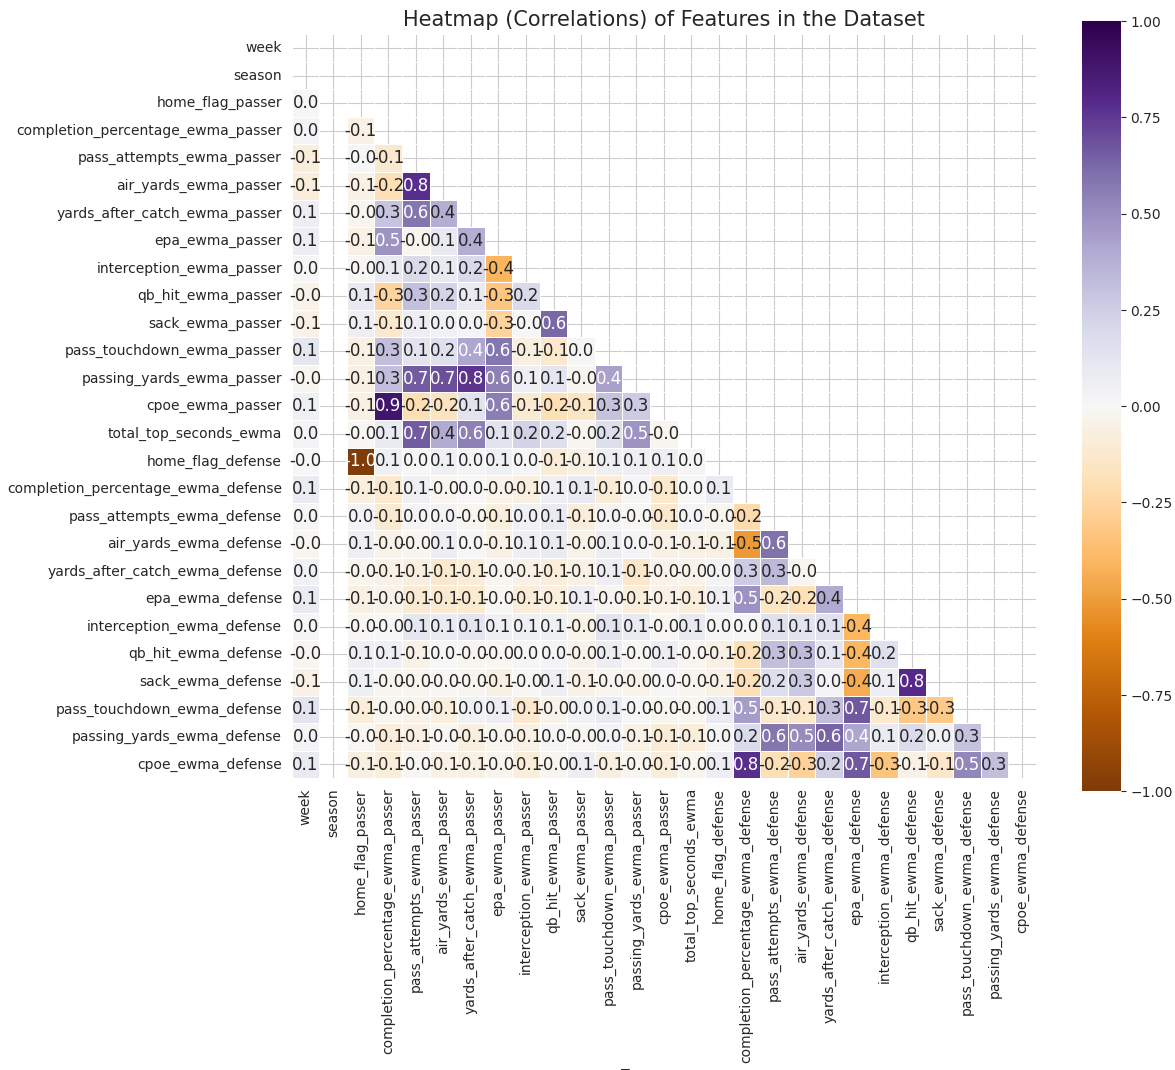

In [56]:
# Create a correlation for the dataset.
dataset_corr = df.corr()

# Drop Agent_ID from correlation dataset.
dataset_corr = dataset_corr.drop(['passing_yards'], axis=1)
dataset_corr = dataset_corr.drop(['passing_yards'], axis=0)

# Create a correlation matrix. Only bottom left corner valued.
mask = np.zeros_like(dataset_corr.round(4))
mask[np.triu_indices_from(mask)] = True

# Generate the corrleation matrix (heatmap) using Seaborn.
with sns.axes_style("whitegrid"):
    f, ax = plt.subplots(figsize=(12, 10))
    ax = sns.heatmap(dataset_corr.round(2), mask=mask, vmax=1, center=0, vmin=-1, square=True,
                     cmap='PuOr', linewidths=.5, annot=True, annot_kws={"size": 12}, fmt='.1f')
    plt.title('Heatmap (Correlations) of Features in the Dataset', fontsize=15)
    plt.xlabel('Features', fontsize=15)
    plt.ylabel('Features', fontsize=15)
plt.show()

In [104]:
df.isnull().sum()
final_df = df.dropna()

In [105]:
from rapidfuzz import process, fuzz
import pandas as pd
import re

# 1. Prepare Name Lists
final_names = final_df['passer_player_name'].unique().tolist()
prop_names = prop_df['player_name'].unique().tolist()
search_choices = final_names # List to search against


def clean_name_minimal(name):
    """Standardizes names for better partial ratio matching: Lowercase, remove periods/suffixes."""
    name = name.lower()
    # Only remove the period, keep the initial separate (e.g., 'J.Hurts' -> 'j hurts')
    name = name.replace('.', ' ') 
    # Remove common suffixes
    name = re.sub(r'\s+(jr|sr|ii|iii|iv)\.?$', '', name)
    # Remove any extra spaces created
    name = re.sub(r'\s+', ' ', name).strip()
    return name


# 2. Create the Cleaned Search List and a Map to Retrieve Original Names
# NOTE: We clean prop_names (the queries) but keep final_names (the choices) as they are for the original map
cleaned_choices = [clean_name_minimal(n) for n in search_choices]

# Map from CLEANED final_name back to ORIGINAL final_name (for merge key)
clean_to_original_map = {clean_name_minimal(n): n for n in final_names}


# 3. Perform the Fuzzy Matching and Build the Match List (for ALL names)
matched_names = []
# partial_ratio requires a lower threshold than token_set, try 80
SCORE_THRESHOLD = 80

for name_prop in prop_names:
    # Clean the current name_prop for the query
    cleaned_query = clean_name_minimal(name_prop)

    best_match = process.extractOne(
        query=cleaned_query,
        choices=cleaned_choices,
        # --- KEY CHANGE: Use partial_ratio ---
        scorer=fuzz.partial_ratio,
        score_cutoff=SCORE_THRESHOLD
    )

    if best_match:
        # best_match is (cleaned_match, score, index)
        cleaned_match_name = best_match[0]
        score = best_match[1]
        
        # Get the original (uncleaned) name from final_df using the map
        original_final_name = clean_to_original_map.get(cleaned_match_name)

        matched_names.append({
            'prop_name': name_prop,
            'final_name_match': original_final_name,
            'similarity_score': score
        })
    else:
        # No match found above the threshold
        matched_names.append({
            'prop_name': name_prop,
            'final_name_match': None,
            'similarity_score': 0.0
        })

# 4. Create Match DataFrame and Map for Merging
match_df = pd.DataFrame(matched_names)

# Display sample results
print("--- Sample Name Matches (prop_df -> final_df) ---")
print(match_df[['prop_name', 'final_name_match', 'similarity_score']].sort_values(by='similarity_score', ascending=False))
print("-" * 50)
print("\n--- Unmatched Players (Score < {}) ---".format(SCORE_THRESHOLD))
print(match_df[match_df['final_name_match'].isna()])


# 5. Perform the Merge
# Create the map from prop_name (full name) to final_name (abbreviated name)
valid_matches = match_df.dropna(subset=['final_name_match'])
name_map = valid_matches.set_index('prop_name')['final_name_match'].to_dict()

# Create the common key column in prop_df using the map
prop_df['passer_player_name'] = prop_df['player_name'].map(name_map)
prop_df['gameday'] = pd.to_datetime(prop_df['event_commence_time']).dt.strftime('%Y-%m-%d')
# Merge the DataFrames on the newly created common key
merged_df = final_df.merge(
    prop_df.drop(columns=['player_name','outcome_type']).drop_duplicates(), # Drop the redundant name column from prop_df
    on=['passer_player_name','gameday'],
    how='left'
)

print("\n✅ Merge complete.")
print(merged_df)
merged_df.dropna(subset='sport_key', inplace=True)

--- Sample Name Matches (prop_df -> final_df) ---
            prop_name final_name_match  similarity_score
14     Tua Tagovailoa     T.Tagovailoa         95.652174
26     Caleb Williams       C.Williams         94.736842
11       Dak Prescott       D.Prescott         94.736842
4     Trevor Lawrence       T.Lawrence         94.736842
19     Baker Mayfield       B.Mayfield         94.736842
9    Matthew Stafford       M.Stafford         94.736842
25     Jayden Daniels        J.Daniels         94.117647
21    Patrick Mahomes        P.Mahomes         94.117647
30      Lamar Jackson        L.Jackson         94.117647
15     Justin Herbert        J.Herbert         94.117647
12     Dillon Gabriel        D.Gabriel         94.117647
33     Marcus Mariota        M.Mariota         94.117647
6     Spencer Rattler        S.Rattler         94.117647
5         Sam Darnold        S.Darnold         94.117647
13      Aaron Rodgers        A.Rodgers         94.117647
27       Kyler Murray         K.Murray

C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\dateutil\parser\_parser.py:1207: UnknownTimezoneWarning: tzname EDT identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


In [106]:
merged_df.drop(columns=['event_id','event_name','sport_key','event_commence_time','updated_dttm'], axis=1, inplace=True)

In [108]:
# Identify categorical columns to be encoded
categorical_cols = ['passer_player_name', 'posteam', 'defteam', 'roof', 'surface']

# Perform one-hot encoding
final_df = pd.get_dummies(merged_df, columns=categorical_cols, drop_first=True)
final_df.drop(['gameday','market_type'], axis=1, inplace=True)
final_df['Status'] = (final_df['passing_yards'] > final_df['point_value']).astype(int)

In [110]:
X = final_df.drop(['passing_yards','week','season','point_value','Status'], axis=1)  # Features
y = final_df['Status']              # Target

# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 14, number of negative: 16
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 30, number of used features: 0
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.466667 -> initscore=-0.133531
[LightGBM] [Info] Start training from score -0.133531
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because t

C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


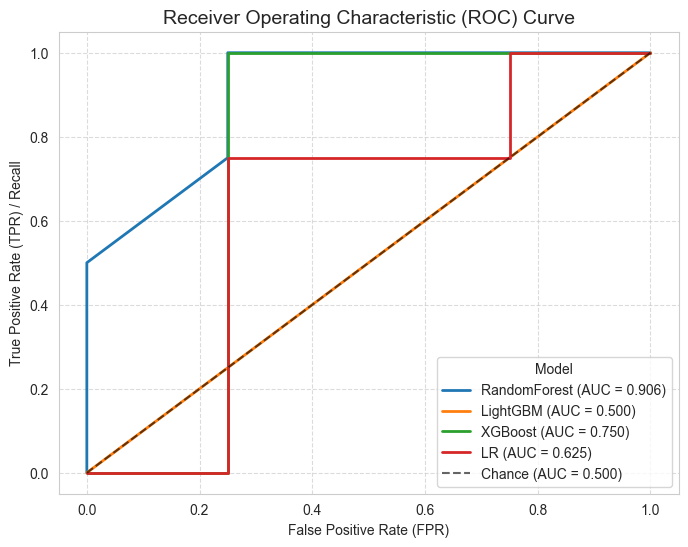

In [111]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve
)

# Instantiate the models
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'LR': LogisticRegression(random_state=42),
}

roc_data = {}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    # 1. Get predicted class labels
    y_pred = model.predict(X_test)
    
    # 2. Get predicted probabilities for the positive class (required for AUC-ROC and ROC Curve)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # Fallback (though all models above have predict_proba)
        y_proba = y_pred 
    
    # Calculate classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # Calculate AUC-ROC
    try:
        auc_roc = roc_auc_score(y_test, y_proba)
    except ValueError:
        auc_roc = np.nan 

    # Store metrics
    results[name] = {
        'Accuracy': accuracy, 
        'Precision': precision, 
        'Recall': recall, 
        'F1-Score': f1,
        'AUC-ROC': auc_roc
    }
    
    # Calculate ROC Curve points (FPR, TPR, thresholds)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': auc_roc}


# -----------------------------------------------
# 1. Print the comparison results
# -----------------------------------------------
results_df = pd.DataFrame(results).T.sort_values(by='AUC-ROC', ascending=False)
print("--- Classification Model Comparison ---")
print(results_df)

best_model_name = results_df.index[0]
print(f"\nThe best performing model based on AUC-ROC is: {best_model_name}")

# -----------------------------------------------
# 2. Plot the AUC-ROC Curve
# -----------------------------------------------

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid") # Use a clean seaborn style

# Plot ROC curve for each model
for name, data in roc_data.items():
    plt.plot(
        data['fpr'], data['tpr'], 
        label=f"{name} (AUC = {data['auc']:.3f})", 
        linewidth=2
    )

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.500)', alpha=0.6)

# Customize the plot
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc='lower right', title='Model')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [112]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# Instantiate the RandomForest model
rf = RandomForestClassifier(random_state=42)

# Perform Grid Search with cross-validation
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid,
                              cv=5, scoring='neg_root_mean_squared_error',
                              n_jobs=-1, verbose=1)

grid_search_rf.fit(X_train, y_train)

# Get the best model and its parameters
tuned_rf = grid_search_rf.best_estimator_
rf_best_params = grid_search_rf.best_params_
print(f"Best parameters found for RandomForest: {grid_search_rf.best_params_}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits


C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
405 fits failed out of a total of 810.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
308 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py", line 471, in _validate_params


Best parameters found for RandomForest: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [113]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

rf_tuned_model = RandomForestClassifier(**rf_best_params, random_state=42)

rf_tuned_model.fit(X_train, y_train)
y_pred = rf_tuned_model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, zero_division=0)
y_proba = rf_tuned_model.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

# --- Print Results ---
print(f'Accuracy: {accuracy:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'AUC-ROC: {auc_roc:.4f}')
print(f'Confusion Matrix:\n{conf_matrix}')

Accuracy: 0.8750
F1 Score: 0.8889
AUC-ROC: 0.9375
Confusion Matrix:
[[3 1]
 [0 4]]


In [114]:
import joblib
# Save the tuned LGBM model for rushing yards
#joblib.dump(rf_tuned_model, 'rf_passing_model.joblib')

# Save the tuned Random Forest model for rushing yards
joblib.dump(rf_tuned_model, 'lgbm_passing_model.joblib')

print("All optimal models have been saved to disk.")

All optimal models have been saved to disk.
